# Group Assignment : Tick Bites Analysis

### Import Libraries

In [1]:
import pandas as pd
import geopandas as gpd

In [2]:
gdf = gpd.read_file("AssignmentData/TickBites_Dec16/NL_TickBites_Dec16_RD_New.shp")
gdf.head()

,OBJECTID,field_1,field_2,field_3,field_4,field_5,field_6,field_7,field_8,field_9,field_10,field_11,field_12,field_13,field_14,field_15,geometry
0,1,1,NaT,NaT,387000.000000,174000.000000,None,None,None,None,None,heide,wandelen,None,1000,De rode kring openbaarde zich in februari van ...,POINT (174000 387000)
1,2,2,2002-01-01,2012-06-05,427805.600595,60001.108122,3252LE,None,Goedereede,Goeree-Overflakkee,Zuid-Holland,tuin,tuinieren,1960,18,zonnen,POINT (60001.108 427805.601)
2,3,3,2002-01-01,2012-07-14,566788.639714,198817.497861,None,None,None,None,None,tuin,spelen,None,18,None,POINT (198817.498 566788.64)
3,4,5,2002-07-01,2012-03-31,511841.215297,202893.287001,8061RV,None,Hasselt,Zwartewaterland,Overijssel,tuin-weiland-moerasgebied,tuinieren,1960,14,koeien ophalen,POINT (202893.287 511841.215)
4,5,7,2003-01-01,2013-01-27,536045.842573,213043.090819,None,None,Zwolle,Zwolle,Overijssel,bos,wandelen,1965,13,None,POINT (213043.091 536045.843)


- Renaming column names

In [3]:
gdf.rename({
    "field_1": "ID",
    "field_2": "reporting_date",
    "field_3": "tick_bite_date",
    "field_4": "longitude",
    "field_5": "latitude",
    "field_6": "postal_code",
    "field_7": "Unknown_1",
    "field_8": "city",
    "field_9": "municipality",
    "field_10": "province",
    "field_11": "environment",
    "field_12": "activity",
    "field_13": "year_of_birth",
    "field_14": "zoom",
    "field_15": "general_remarks",

}, axis=1, inplace=True)

- CRS of the geodataframe

In [4]:
gdf.crs

<Projected CRS: EPSG:28992>
Name: Amersfoort / RD New
Axis Info [cartesian]:
- X[east]: Easting (metre)
- Y[north]: Northing (metre)
Area of Use:
- name: Netherlands - onshore, including Waddenzee, Dutch Wadden Islands and 12-mile offshore coastal zone.
- bounds: (3.2, 50.75, 7.22, 53.7)
Coordinate Operation:
- name: RD New
- method: Oblique Stereographic
Datum: Amersfoort
- Ellipsoid: Bessel 1841
- Prime Meridian: Greenwich

## Time Series Variation of Tick Bites Across Entire Study Area

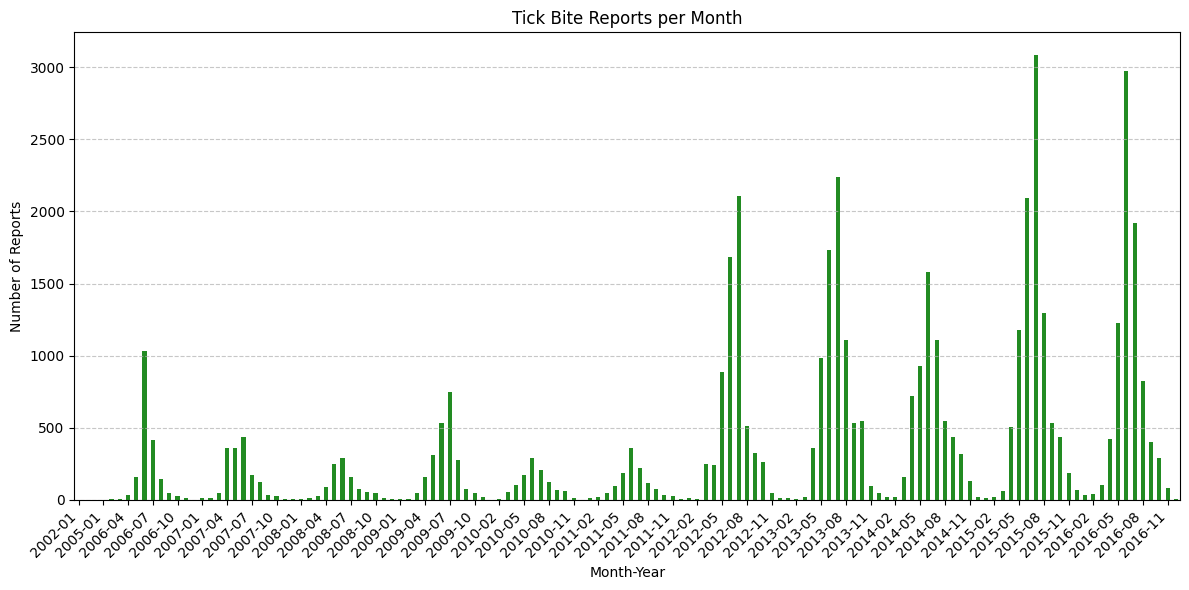

In [5]:
import matplotlib.pyplot as plt

gdf["reporting_date"] = pd.to_datetime(gdf["reporting_date"])
gdf['month_year'] = gdf['reporting_date'].dt.to_period('M')
monthly_counts = gdf.groupby("month_year").size().sort_index()

plt.figure(figsize=(12, 6))
monthly_counts.plot(kind='bar', color='forestgreen')

plt.title("Tick Bite Reports per Month")
plt.xlabel("Month-Year")
plt.ylabel("Number of Reports")

# Reduce number of xticks
xticks = plt.gca().get_xticks()
labels = plt.gca().get_xticklabels()
plt.xticks(xticks[::3], [label.get_text() for i, label in enumerate(labels) if i % 3 == 0], rotation=45, ha='right')

plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


## Age Distribution at the time of tick bite

In [6]:
import pandas as pd
import numpy as np

# Replace "None" strings and other non-numeric values with NaN
gdf["year_of_birth_clean"] = pd.to_numeric(gdf["year_of_birth"], errors="coerce")

# If you need it as a datetime (e.g., 1980 → 1980-01-01)
gdf["date_of_birth"] = pd.to_datetime(gdf["year_of_birth_clean"], format="%Y", errors="coerce")

# (Optional) Calculate age at time of tick bite
gdf["tick_bite_date"] = pd.to_datetime(gdf["reporting_date"], errors="coerce")
gdf["age_at_bite"] = gdf["tick_bite_date"].dt.year - gdf["date_of_birth"].dt.year

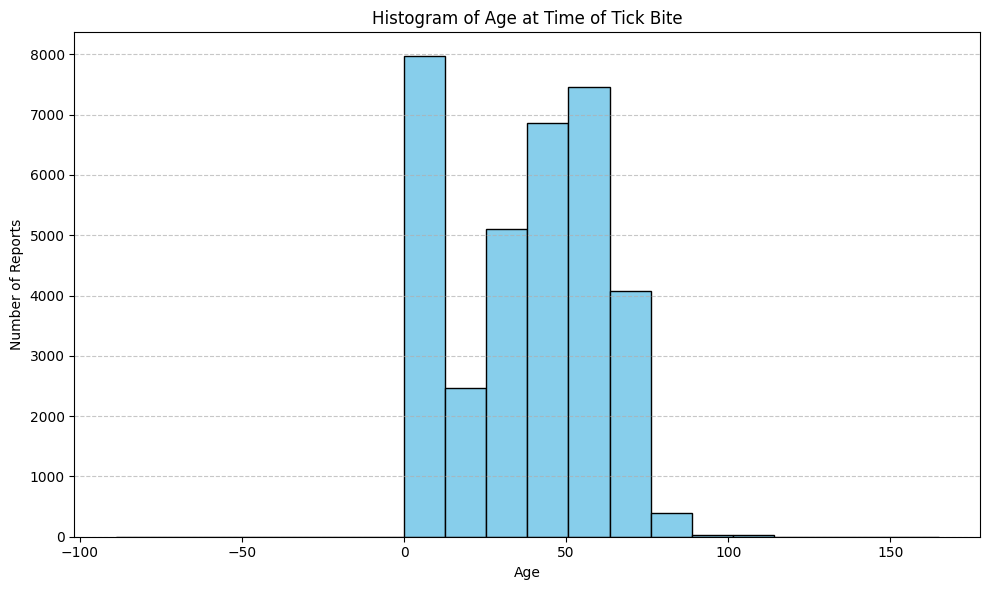

In [7]:
import matplotlib.pyplot as plt

# Drop NaN values for plotting
age_data = gdf["age_at_bite"].dropna()

# Plot histogram
plt.figure(figsize=(10, 6))
plt.hist(age_data, bins=20, color='skyblue', edgecolor='black')

plt.title("Histogram of Age at Time of Tick Bite")
plt.xlabel("Age")
plt.ylabel("Number of Reports")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Distribution of Activities

In [9]:
def categorize_activity(activity):
    if activity is None:
        return "Unknown"
    
    a = activity.lower()
    
    if "wandelen" in a:
        return "Walking"
    elif "honduitlaten" in a or "hond uitlaten" in a:
        return "Dog walking"
    elif "tuinieren" in a:
        return "Gardening"
    elif "spelen" in a:
        return "Playing"
    elif "picknicken" in a or "picknick" in a:
        return "Picnicking"
    elif "groenbeheer" in a:
        return "Green maintenance"
    elif "weetniet" in a or "weet niet" in a:
        return "Unknown"
    elif "anders" in a:
        return "Other"
    else:
        return "Other"

gdf["activity_grouped"] = gdf["activity"].apply(categorize_activity)

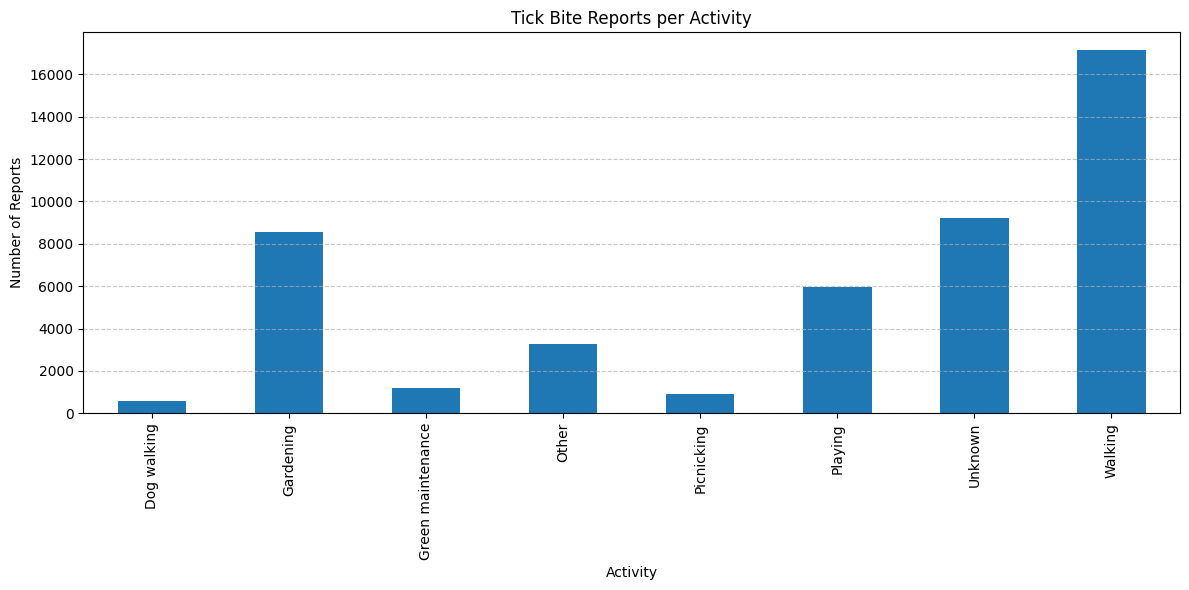

In [10]:
import matplotlib.pyplot as plt

activity_count = gdf.groupby("activity_grouped").size().sort_index()

plt.figure(figsize=(12, 6))
activity_count.plot(kind='bar')

plt.title("Tick Bite Reports per Activity")
plt.xlabel("Activity")
plt.ylabel("Number of Reports")
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


## Distribution of Environments

In [11]:
def categorize_environment(env):
    if env is None:
        return "Unknown"
    
    e = env.lower()
    
    if "tuin" in e:
        return "Garden"
    elif "bos" in e:
        return "Forest"
    elif "heide" in e:
        return "Heather"
    elif "weiland" in e:
        return "Pasture"
    elif "stadspark" in e:
        return "Urban Park"
    elif "duinen" in e:
        return "Dunes"
    elif "moerasgebied" in e:
        return "Wetlands"
    elif "weet niet" in e or "weetniet" in e:
        return "Unknown"
    elif "anders" in e:
        return "Other"
    else:
        return "Other"

gdf["environment_grouped"] = gdf["environment"].apply(categorize_environment)

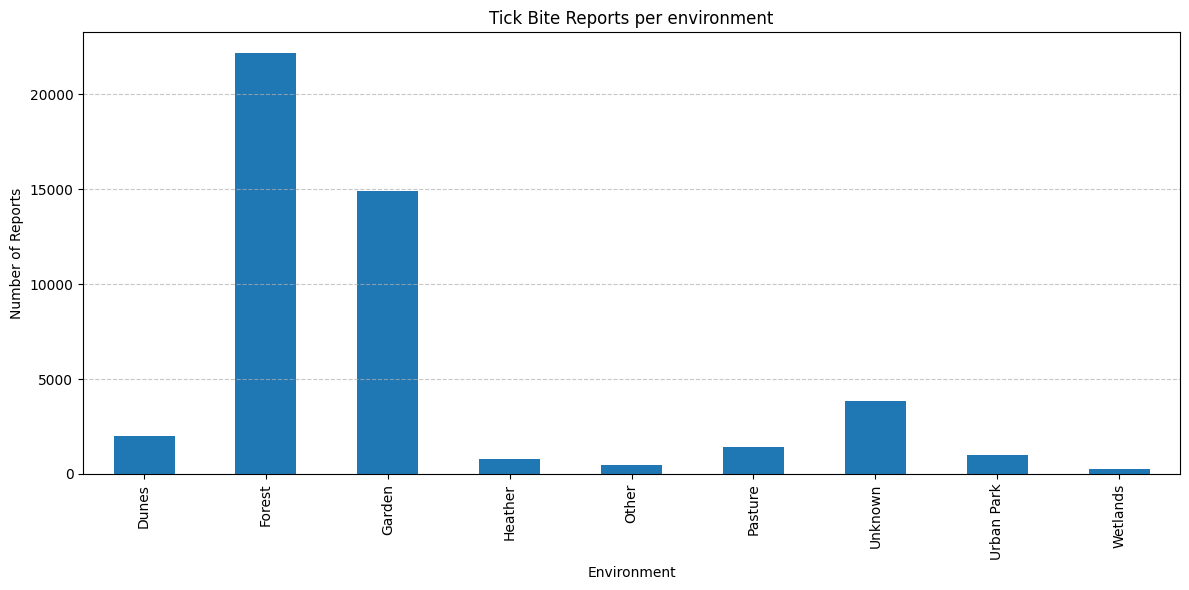

In [12]:
import matplotlib.pyplot as plt

activity_count = gdf.groupby("environment_grouped").size().sort_index()

plt.figure(figsize=(12, 6))
activity_count.plot(kind='bar')

plt.title("Tick Bite Reports per environment")
plt.xlabel("Environment")
plt.ylabel("Number of Reports")

plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Sptial Distribution of Ticks Bites (in a 10km Circumradius Hex Cell)

<Axes: >

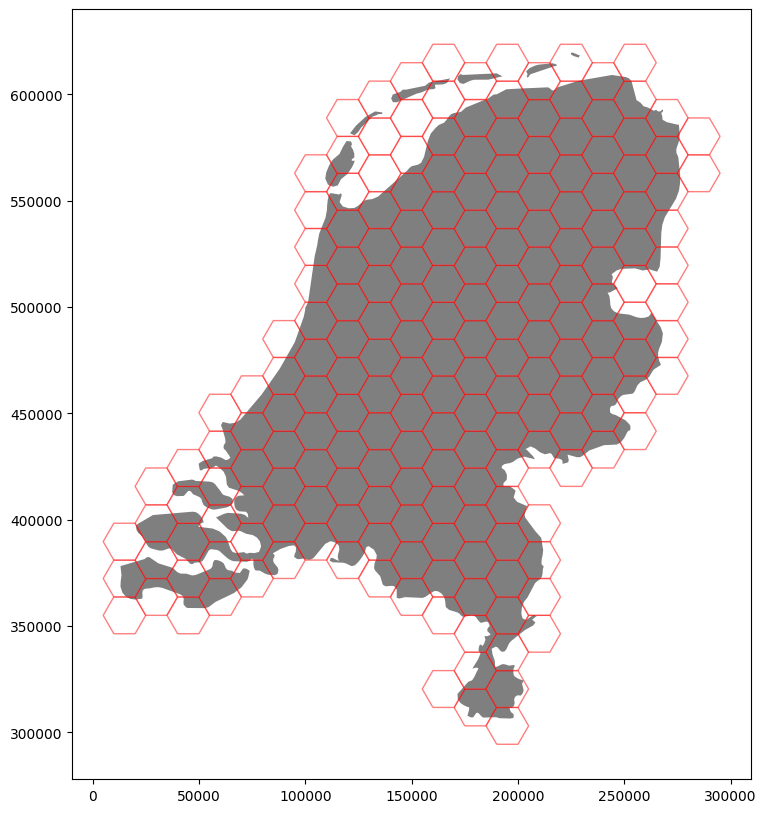

In [13]:
import geopandas as gpd
import geohexgrid as ghg

# # Load New Zealand territorial authorities projected in EPSG 2193 (NZTM)
neth = gpd.read_file("/home/saheel/netherlands_outer.geojson")

# Cover it minimally with hexagons of circumradius 10 kilometres
grid = ghg.make_grid_from_gdf(neth, R=10_000)

# # Plot
base = neth.to_crs("EPSG:28992").plot(color="black", figsize=(10, 10), aspect="equal")
grid.plot(ax=base, color="white", edgecolor="red", alpha=0.5)

In [14]:
import geopandas as gpd
import matplotlib.pyplot as plt

# Ensure both GeoDataFrames use the same CRS
gdf = gdf.to_crs(grid.crs)

# Perform spatial join: assign each point to a hex cell
joined = gpd.sjoin(gdf, grid, how="inner", predicate="within")

# Count the number of points in each hex (using the grid's index or ID)
hex_counts = joined.groupby(joined.index_right).size()

# Add counts to the original grid GeoDataFrame
grid["tick_count"] = grid.index.map(hex_counts).fillna(0).astype(int)

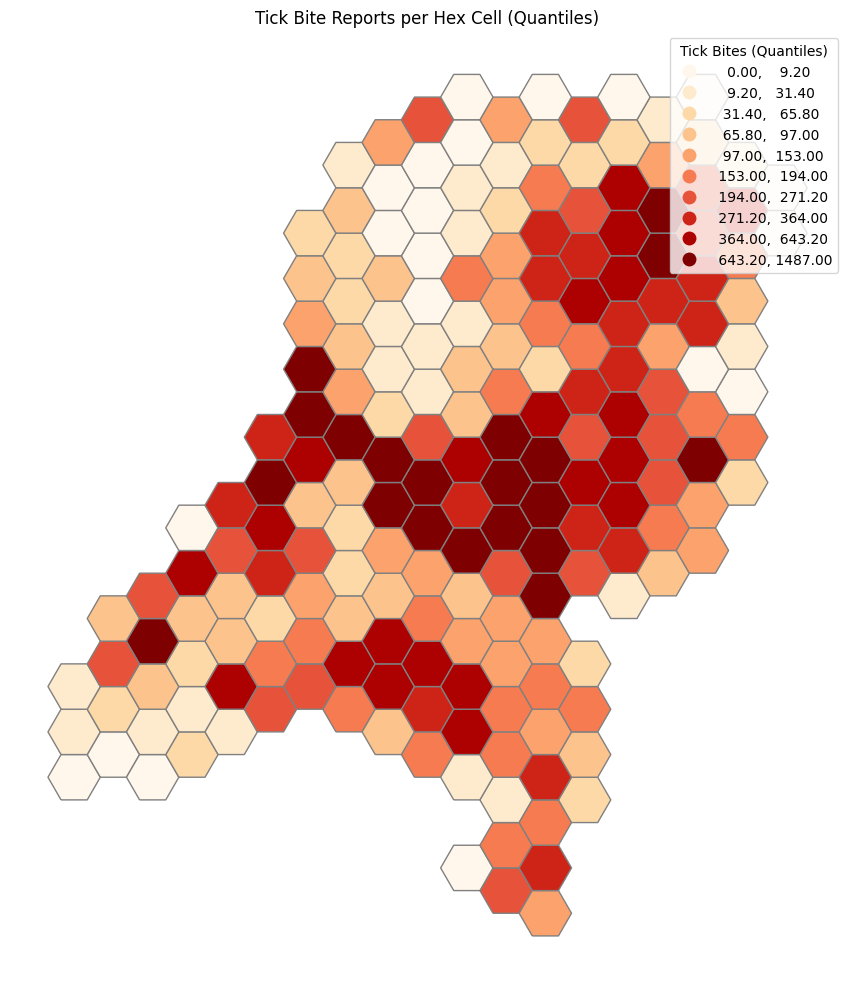

In [15]:
import mapclassify

fig, ax = plt.subplots(figsize=(10, 10))

# Plot with quantile-based classification
grid.plot(
    column="tick_count",
    scheme="Quantiles",
    k=10,  # Number of quantile classes
    cmap="OrRd",
    edgecolor="grey",
    legend=True,
    ax=ax,
    legend_kwds={"title": "Tick Bites (Quantiles)"}
)

plt.title("Tick Bite Reports per Hex Cell (Quantiles)")
plt.axis("off")
plt.tight_layout()
plt.show()


## Preparing data for Machine Learning (DO NOT RUN BREAKING CODE)

In [ ]:
gdf_filtered = gdf[gdf["month_year"] >= "2012-01"]
tick_points = gpd.sjoin(gdf_filtered, grid, how="left", predicate="within")
tick_points["cell_id"] = tick_points.index_right
tick_points["month"] = tick_points["reporting_date"].dt.month
grouped = tick_points.groupby(["cell_id", "month"])

tick_counts = grouped.size().rename("tick_count")
avg_age = grouped["age_at_bite"].mean().rename("avg_age")

env_dist = (
    tick_points.groupby(["cell_id", "month"])["environment_grouped"]
    .value_counts(normalize=True)
    .unstack(fill_value=0)
)

activity_dist = (
    tick_points.groupby(["cell_id", "month"])["activity_grouped"]
    .value_counts(normalize=True)
    .unstack(fill_value=0)
)

features = pd.concat([tick_counts, avg_age, env_dist, activity_dist], axis=1).reset_index()

In [121]:
features

,cell_id,month,tick_count,avg_age,Dunes,Forest,Garden,Heather,Other,Pasture,...,Urban Park,Wetlands,Dog walking,Gardening,Green maintenance,Other,Picnicking,Playing,Unknown,Walking
0,11.0,2,1,25.000000,0.0,0.000000,1.000000,0.0,0.0,0.000000,...,0.000000,0.0,0.0,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
1,11.0,3,1,NaN,0.0,0.000000,1.000000,0.0,0.0,0.000000,...,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
2,11.0,4,17,40.583333,0.0,0.411765,0.352941,0.0,0.0,0.058824,...,0.058824,0.0,0.0,0.235294,0.000000,0.000000,0.000000,0.058824,0.294118,0.411765
3,11.0,5,37,31.521739,0.0,0.648649,0.243243,0.0,0.0,0.108108,...,0.000000,0.0,0.0,0.108108,0.000000,0.027027,0.000000,0.162162,0.216216,0.486486
4,11.0,6,58,37.818182,0.0,0.551724,0.241379,0.0,0.0,0.103448,...,0.000000,0.0,0.0,0.103448,0.051724,0.034483,0.017241,0.086207,0.206897,0.500000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1687,339.0,10,2,35.000000,0.0,0.000000,1.000000,0.0,0.0,0.000000,...,0.000000,0.0,0.0,0.500000,0.000000,0.000000,0.000000,0.000000,0.500000,0.000000
1688,339.0,11,1,63.000000,0.0,0.000000,1.000000,0.0,0.0,0.000000,...,0.000000,0.0,0.0,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
1689,354.0,5,1,NaN,0.0,0.000000,0.000000,1.0,0.0,0.000000,...,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
1690,358.0,4,1,NaN,0.0,0.000000,0.000000,0.0,0.0,0.000000,...,0.000000,0.0,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000


In [16]:
import pandas as pd
import matplotlib.pyplot as plt

# Link features_df with grid via "cell_id"

#grid.drop("cell_id", inplace=True, axis=1)
grid_1 = grid.reset_index().rename(columns={"index": "cell_id"})
merged = grid_1.merge(features, on="cell_id")
# # # Ensure 'month' column is datetime and extract month if not already
# # merged["month"] = pd.to_datetime(merged["month"], errors="coerce")
# # merged["month_str"] = merged["month"].dt.strftime("%Y-%m")

# # Get unique months and sort
# months = sorted(merged["month"].unique())

# # Prepare subplots
# n_months = len(months)
# ncols = 4
# nrows = (n_months + ncols - 1) // ncols
# fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 5 * nrows))
# axes = axes.flatten()

# # Plot each month
# for i, month in enumerate(months):
#     ax = axes[i]
#     month_data = merged[merged["month"] == month]
#     month_data.plot(column="tick_count", ax=ax, legend=False, cmap="Reds", edgecolor="grey")
#     ax.set_title(month, fontweight="bold")
#     ax.axis("off")

# # Hide any extra subplots
# for j in range(i + 1, len(axes)):
#     axes[j].axis("off")

# plt.tight_layout()
# plt.show()


NameError: name 'features' is not defined

In [152]:
merged = merged.dropna()

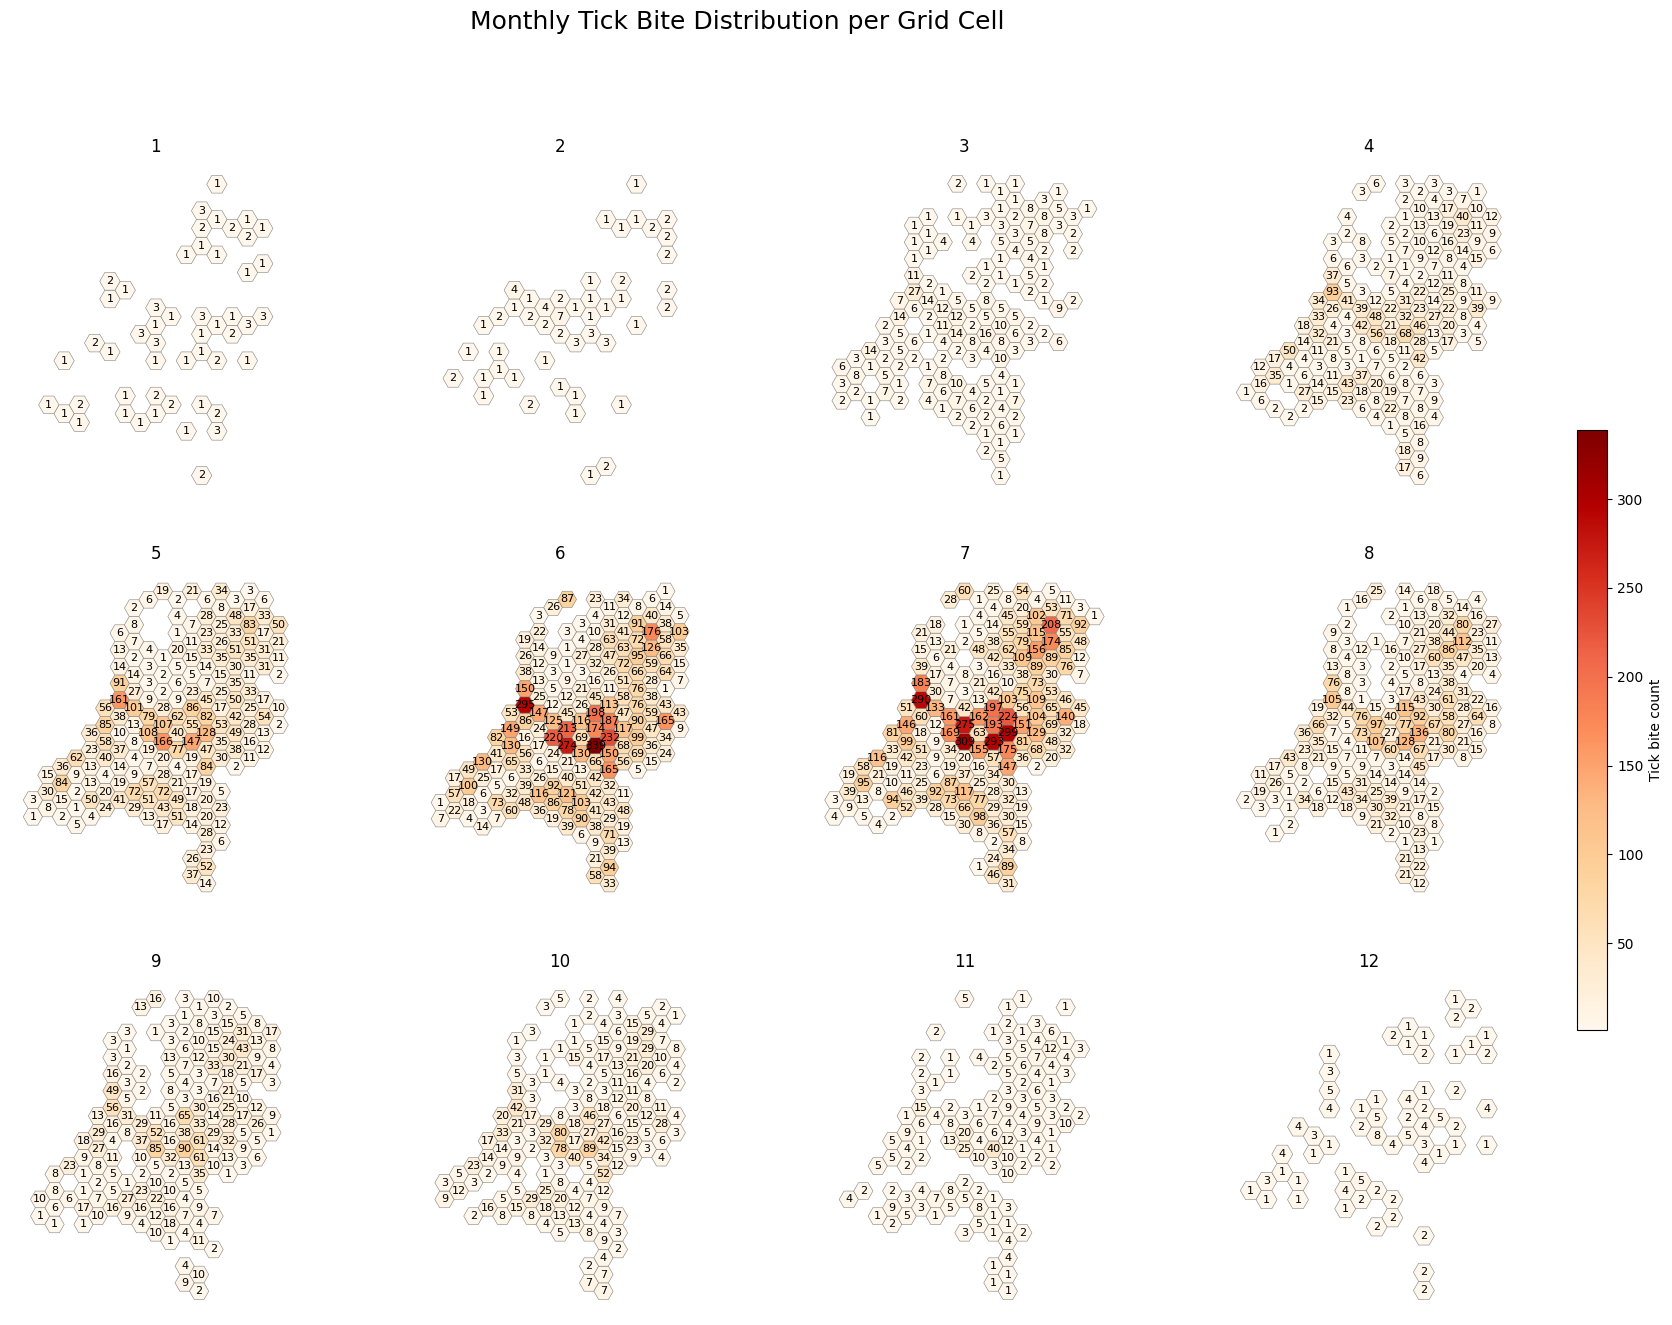

In [157]:
import matplotlib as mpl

# Calculate global min and max for consistent color scale
merged
vmin = merged["tick_count"].min()
vmax = merged["tick_count"].max()

fig, axs = plt.subplots(3, 4, figsize=(20, 15))
for i, month in enumerate(sorted(merged["month"].unique())):
    ax = axs[i // 4, i % 4]
    merged[merged["month"] == month].plot(
        column="tick_count",
        cmap="OrRd",
        linewidth=0.4,
        ax=ax,
        edgecolor="grey",
        vmin=vmin,
        vmax=vmax,
        legend=False
    )
    ax.set_title(month)
    ax.axis("off")

    # Annotate each hex cell with the tick count
    for _, row in merged[merged["month"] == month].iterrows():
        # if row["tick_count"] > 0:  # Optional: skip labeling 0 counts
        x, y = row.geometry.centroid.coords[0]
        ax.text(x, y, str(int(row["tick_count"])), fontsize=8, ha='center', va='center')

# Create a common colorbar
cax = fig.add_axes([0.92, 0.3, 0.015, 0.4])  # [left, bottom, width, height]
sm = mpl.cm.ScalarMappable(cmap="OrRd", norm=mpl.colors.Normalize(vmin=vmin, vmax=vmax))
sm._A = []  # Dummy array for ScalarMappable
fig.colorbar(sm, cax=cax, label="Tick bite count")


fig.suptitle("Monthly Tick Bite Distribution per Grid Cell", fontsize=18)
#plt.tight_layout()
plt.show()

In [172]:
# Get the current columns
cols = list(merged.columns)

# Rename by index — assuming you posted the correct order
# cols[cols.index('Other')] = 'Other_environment'
# cols[cols.index('Other', cols.index('Other') + 1)] = 'Other_activity'
cols[cols.index('Unknown')] = 'Unknown_environment'
cols[cols.index('Unknown')] = 'Unknown_activity'

# Assign back to the dataframe
merged.columns = cols

In [166]:
cols[cols.index('Other')] = 'Other_activity'

In [168]:
merged.columns = cols

In [173]:
merged.columns

Index(['cell_id', 'geometry', 'month', 'tick_count', 'avg_age', 'Dunes',
       'Forest', 'Garden', 'Heather', 'Other_environment', 'Pasture',
       'Unknown_environment', 'Urban Park', 'Wetlands', 'Dog walking',
       'Gardening', 'Green maintenance', 'Other_activity', 'Picnicking',
       'Playing', 'Unknown_activity', 'Walking'],
      dtype='object')

In [174]:
merged.to_file("monthly_ticks_bites.geojson")

## Create A Regression Model to Predict Tick Count For Each Hex Cell

In [2]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

In [3]:
gdf = gpd.read_file("monthly_ticks_bites.geojson")
gdf.head()

,cell_id,month,tick_count,avg_age,Dunes,Forest,Garden,Heather,Other_environment,Pasture,...,Wetlands,Dog walking,Gardening,Green maintenance,Other_activity,Picnicking,Playing,Unknown_activity,Walking,geometry
0,11,2,1,25.000000,0.0,0.000000,1.000000,0.000000,0.0,0.000000,...,0.0,0.0,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,"POLYGON ((175000 303108.891, 185000 303108.891..."
1,11,4,17,40.583333,0.0,0.411765,0.352941,0.000000,0.0,0.058824,...,0.0,0.0,0.235294,0.000000,0.000000,0.000000,0.058824,0.294118,0.411765,"POLYGON ((175000 303108.891, 185000 303108.891..."
2,11,5,37,31.521739,0.0,0.648649,0.243243,0.000000,0.0,0.108108,...,0.0,0.0,0.108108,0.000000,0.027027,0.000000,0.162162,0.216216,0.486486,"POLYGON ((175000 303108.891, 185000 303108.891..."
3,11,6,58,37.818182,0.0,0.551724,0.241379,0.000000,0.0,0.103448,...,0.0,0.0,0.103448,0.051724,0.034483,0.017241,0.086207,0.206897,0.500000,"POLYGON ((175000 303108.891, 185000 303108.891..."
4,11,7,46,42.606061,0.0,0.456522,0.347826,0.021739,0.0,0.043478,...,0.0,0.0,0.173913,0.021739,0.000000,0.043478,0.043478,0.130435,0.586957,"POLYGON ((175000 303108.891, 185000 303108.891..."


In [4]:
gdf.shape

(1585, 22)

In [5]:
gdf.isnull().sum()

cell_id                0
month                  0
tick_count             0
avg_age                0
Dunes                  0
Forest                 0
Garden                 0
Heather                0
Other_environment      0
Pasture                0
Unknown_environment    0
Urban Park             0
Wetlands               0
Dog walking            0
Gardening              0
Green maintenance      0
Other_activity         0
Picnicking             0
Playing                0
Unknown_activity       0
Walking                0
geometry               0
dtype: int64

In [7]:
gdf.columns

Index(['cell_id', 'month', 'tick_count', 'avg_age', 'Dunes', 'Forest',
       'Garden', 'Heather', 'Other_environment', 'Pasture',
       'Unknown_environment', 'Urban Park', 'Wetlands', 'Dog walking',
       'Gardening', 'Green maintenance', 'Other_activity', 'Picnicking',
       'Playing', 'Unknown_activity', 'Walking', 'geometry', 'month_sin',
       'month_cos'],
      dtype='object')

In [6]:
gdf["month_sin"] = np.sin(2 * np.pi * gdf["month"] / 12)
gdf["month_cos"] = np.cos(2 * np.pi * gdf["month"] / 12)

In [9]:
input_features = ['avg_age', 'Dunes', 'Forest','Garden', 'Heather', 'Other_environment', 
 'Pasture','Unknown_environment', 'Urban Park', 'Wetlands', 'Dog walking',
'Gardening', 'Green maintenance', 'Other_activity', 'Picnicking',
'Playing', 'Unknown_activity', 'Walking', 'geometry', 'month_sin','month_cos']
output_label = "tick_count"

In [10]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error, r2_score
import pandas as pd

# Drop geometry for ML
features = gdf[input_features].drop(columns=["geometry"])
target = gdf[output_label]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(features, target, test_size=0.3, random_state=42)

# Initialize and fit the model
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

# Predict
y_pred = rf.predict(X_test)

# Evaluate
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.2f}")

RMSE: 16.97
R²: 0.78


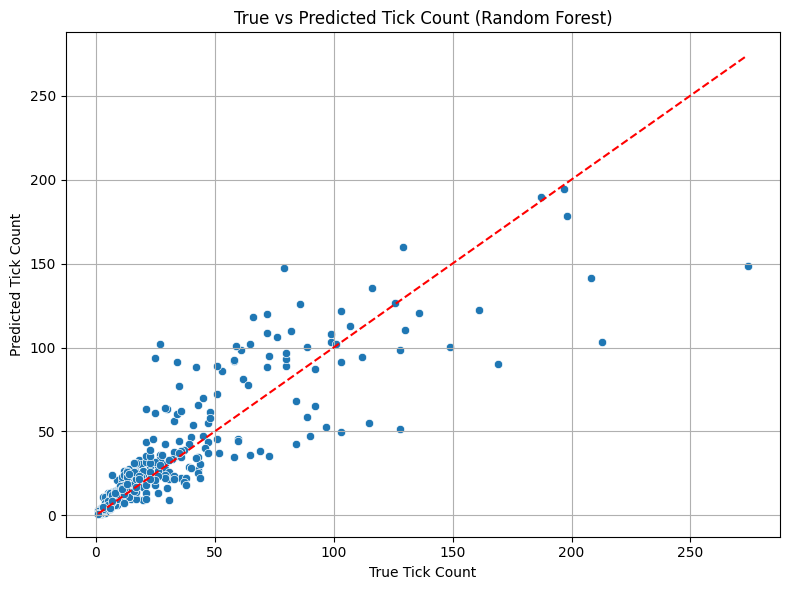

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("True Tick Count")
plt.ylabel("Predicted Tick Count")
plt.title("True vs Predicted Tick Count (Random Forest)")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')  # 1:1 line
plt.grid(True)
plt.tight_layout()
plt.show()

/tmp/ipykernel_177204/382241802.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=feature_importance_df, x='Importance', y='Feature', palette='viridis')


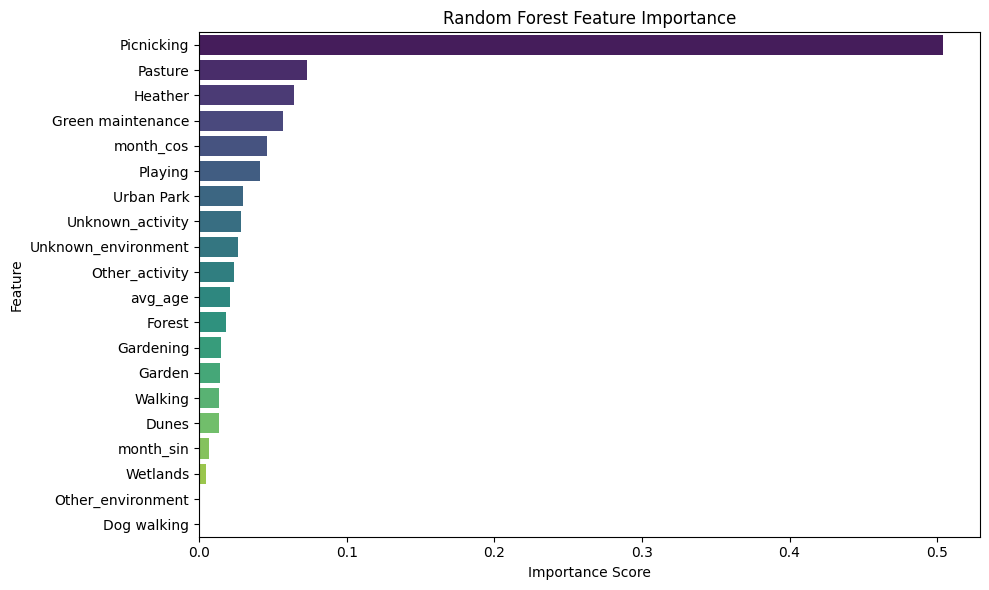

In [16]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Define features used in the model (excluding geometry)
features = [f for f in features if f not in ['geometry']]

# Extract feature importances
importances = rf.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(data=feature_importance_df, x='Importance', y='Feature', palette='viridis')
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


/tmp/ipykernel_177204/1472290707.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_error, x="Tick Count Bin", y="Error", showfliers=False, palette="coolwarm")


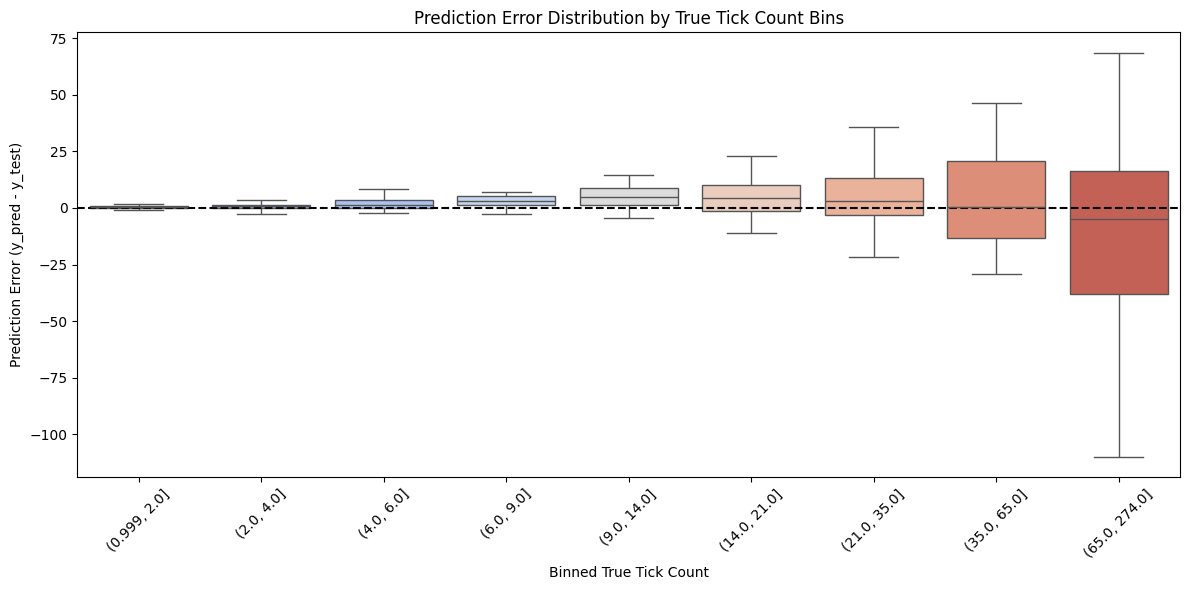

In [19]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate error
error = y_pred - y_test
true = y_test

# Create a DataFrame for plotting
df_error = pd.DataFrame({
    "True Tick Count": true,
    "Error": error
})

# Optional: bin the true values to reduce number of x-ticks
df_error["Tick Count Bin"] = pd.qcut(df_error["True Tick Count"], q=10, duplicates='drop')

# Plot
plt.figure(figsize=(12, 6))
sns.boxplot(data=df_error, x="Tick Count Bin", y="Error", showfliers=False, palette="coolwarm")

plt.axhline(0, color='black', linestyle='--')
plt.title("Prediction Error Distribution by True Tick Count Bins")
plt.xlabel("Binned True Tick Count")
plt.ylabel("Prediction Error (y_pred - y_test)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
